# SVM Nested CV Optimization

This notebook optimizes SVM with the same chronological holdout and race-level nested cross-validation protocol used by the Random Forest workflow.


# 1. Imports

In [110]:
import json
import pathlib
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
)
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, RobustScaler

warnings.filterwarnings("ignore")
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


# 2. Load Configuration

In [111]:
start_path = pathlib.Path(__file__).resolve().parent if "__file__" in dir() else pathlib.Path.cwd().resolve()
for candidate in [start_path, *start_path.parents]:
    config_candidate = candidate / "json-parameters" / "svm" / "svm_optimization_params.json"
    if config_candidate.exists():
        REPO_ROOT = candidate
        CONFIG_PATH = config_candidate
        break
else:
    raise FileNotFoundError("Could not locate json-parameters/svm/svm_optimization_params.json")

with open(CONFIG_PATH, "r") as f:
    config = json.load(f)

print("Config loaded from:", CONFIG_PATH)


Config loaded from: /Users/khaido/Pisa/Data Mining/project/formula1_data_mining_project/json-parameters/svm/svm_optimization_params.json


# 3. Load Data

In [112]:
DATA_PATH = REPO_ROOT / "dataset" / "outputs" / "prediction.csv"
df = pd.read_csv(DATA_PATH)

sort_cols = config["data"].get("sort_by", ["year", "round"])
df = df.sort_values(sort_cols + ["raceId", "driverId"]).reset_index(drop=True)
df["date"] = pd.to_datetime(df["date"])

print("Dataset shape:", df.shape)
print(f"Chronological range: year {df['year'].min()} round {df['round'].min()} -> year {df['year'].max()} round {df['round'].max()}")
print("\nTarget distribution:")
print(df[config["data"]["target_column"]].value_counts())


Dataset shape: (2454, 38)
Chronological range: year 2021 round 1 -> year 2026 round 24

Target distribution:
target
no_points    1234
points        854
podium        366
Name: count, dtype: int64


# 4. Build Feature Matrix and Holdout Split

In [113]:
target_col = config["data"]["target_column"]
drop_cols = config["data"]["drop_columns"]
feature_cols = config["data"].get("feature_columns")
excluded_cols = config["data"].get("excluded_feature_columns", [])
categorical_cols = config["data"].get("categorical_feature_columns", [])
sentinel_impute_cols = config["data"].get("sentinel_impute_columns", [])


def validate_feature_list(name, cols, allow_none=False):
    if cols is None and allow_none:
        return
    if not isinstance(cols, list):
        raise TypeError(f"config['data']['{name}'] must be a list or null")
    duplicated = sorted({col for col in cols if cols.count(col) > 1})
    missing = sorted(set(cols) - set(df.columns))
    forbidden = sorted(set(cols) & set(drop_cols + [target_col]))
    if duplicated:
        raise ValueError(f"Duplicate columns in {name}: {duplicated}")
    if missing:
        raise ValueError(f"Columns in {name} not found in dataset: {missing}")
    if forbidden:
        raise ValueError(f"{name} includes non-feature columns: {forbidden}")


validate_feature_list("feature_columns", feature_cols, allow_none=True)
validate_feature_list("excluded_feature_columns", excluded_cols)
validate_feature_list("categorical_feature_columns", categorical_cols)
validate_feature_list("sentinel_impute_columns", sentinel_impute_cols)

if feature_cols is not None:
    overlap = sorted(set(feature_cols) & set(excluded_cols))
    if overlap:
        raise ValueError(f"Columns cannot be both active and excluded: {overlap}")
    raw_X = df[feature_cols].copy()
    raw_feature_names = list(feature_cols)
else:
    cols_to_drop = drop_cols + [target_col] + excluded_cols
    raw_X = df.drop(columns=cols_to_drop)
    raw_feature_names = raw_X.columns.tolist()

missing_categorical = sorted(set(categorical_cols) - set(raw_feature_names))
if missing_categorical:
    raise ValueError(
        "categorical_feature_columns must be active model features. "
        f"Missing from feature set: {missing_categorical}"
    )

numeric_cols = [col for col in raw_feature_names if col not in categorical_cols]
missing_sentinel_impute = sorted(set(sentinel_impute_cols) - set(raw_feature_names))
if missing_sentinel_impute:
    raise ValueError(
        "sentinel_impute_columns must be active model features. "
        f"Missing from feature set: {missing_sentinel_impute}"
    )


le = LabelEncoder()
y = le.fit_transform(df[target_col])

holdout_cfg = config["data"].get("holdout", {})
test_years = sorted(int(year) for year in holdout_cfg.get("test_years", [2025]))
exclude_years = sorted(int(year) for year in holdout_cfg.get("exclude_years", []))

test_mask = df["year"].isin(test_years)
exclude_mask = df["year"].isin(exclude_years)
train_dev_mask = ~(test_mask | exclude_mask)

train_max_date = pd.to_datetime(df.loc[train_dev_mask, "date"]).max()
test_min_date = pd.to_datetime(df.loc[test_mask, "date"]).min()
if train_max_date >= test_min_date:
    raise ValueError(
        "Holdout must be strictly after the training/development period. "
        f"Got train max date {train_max_date.date()} and test min date {test_min_date.date()}."
    )

train_dev_idx = np.flatnonzero(train_dev_mask.to_numpy())
holdout_idx = np.flatnonzero(test_mask.to_numpy())

raw_X_train_dev = raw_X.iloc[train_dev_idx].reset_index(drop=True)
y_train_dev = y[train_dev_idx]
df_train_dev = df.iloc[train_dev_idx].reset_index(drop=True)

raw_X_holdout = raw_X.iloc[holdout_idx].reset_index(drop=True)
y_holdout = y[holdout_idx]
df_holdout = df.iloc[holdout_idx].reset_index(drop=True)

onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
if categorical_cols:
    train_cat = onehot_encoder.fit_transform(raw_X_train_dev[categorical_cols].astype(str))
    holdout_cat = onehot_encoder.transform(raw_X_holdout[categorical_cols].astype(str))
    encoded_categorical_names = onehot_encoder.get_feature_names_out(categorical_cols).tolist()
else:
    train_cat = np.empty((len(raw_X_train_dev), 0))
    holdout_cat = np.empty((len(raw_X_holdout), 0))
    encoded_categorical_names = []

X_train_dev = pd.concat(
    [raw_X_train_dev[numeric_cols].reset_index(drop=True), pd.DataFrame(train_cat, columns=encoded_categorical_names)],
    axis=1,
)
X_holdout = pd.concat(
    [raw_X_holdout[numeric_cols].reset_index(drop=True), pd.DataFrame(holdout_cat, columns=encoded_categorical_names)],
    axis=1,
)
feature_names = X_train_dev.columns.tolist()
X_train_dev_arr = X_train_dev.values
X_holdout_arr = X_holdout.values

print("Classes:", dict(enumerate(le.classes_)))
print("Raw feature count:", len(raw_feature_names))
print("Encoded feature count:", len(feature_names))
print("Train/development rows:", len(df_train_dev))
print("Holdout rows:", len(df_holdout))


Classes: {0: 'no_points', 1: 'podium', 2: 'points'}
Raw feature count: 12
Encoded feature count: 12
Train/development rows: 1799
Holdout rows: 479


# 5. Race-Level Time-Series Split

In [114]:
def make_race_time_series_splits(df_part, n_splits):
    ordered_races = (
        df_part[["raceId", "date"]]
        .drop_duplicates()
        .sort_values(["date", "raceId"])
        .reset_index(drop=True)
    )
    race_ids = ordered_races["raceId"].to_numpy()
    race_cv = TimeSeriesSplit(n_splits=n_splits)

    for train_race_idx, test_race_idx in race_cv.split(race_ids):
        train_races = set(race_ids[train_race_idx])
        test_races = set(race_ids[test_race_idx])
        train_idx = np.flatnonzero(df_part["raceId"].isin(train_races).to_numpy())
        test_idx = np.flatnonzero(df_part["raceId"].isin(test_races).to_numpy())
        yield train_idx, test_idx


inner_n_splits = config["cv"]["inner_n_splits"]
outer_n_splits = config["cv"]["outer_n_splits"]
outer_splits = list(make_race_time_series_splits(df_train_dev, outer_n_splits))

print("Outer folds:", outer_n_splits)
print("Inner folds:", inner_n_splits)


Outer folds: 5
Inner folds: 3


# 6. Define Base SVM Pipeline

The SVM pipeline now handles sentinel `-1` values before scaling. For each configured sentinel column, the transformer:

1. creates a `{feature}_missing` indicator,
2. replaces `-1` with the median learned from the current training fold,
3. passes the expanded matrix to the scaler and SVC.

This keeps missing-history information without treating `-1` as a real numeric value.


In [115]:
model_cfg = config["model"]


class SentinelMedianImputer(BaseEstimator, TransformerMixin):
    """Replace sentinel values with training medians and append missing indicators."""

    def __init__(self, feature_names=None, sentinel_columns=None, sentinel_value=-1):
        self.feature_names = feature_names
        self.sentinel_columns = sentinel_columns
        self.sentinel_value = sentinel_value

    def fit(self, X, y=None):
        X_arr = np.asarray(X, dtype=float)
        self.feature_names_ = list(self.feature_names) if self.feature_names is not None else [
            f"feature_{idx}" for idx in range(X_arr.shape[1])
        ]
        self.sentinel_columns_ = list(self.sentinel_columns or [])
        self.sentinel_indices_ = [self.feature_names_.index(col) for col in self.sentinel_columns_]

        self.medians_ = {}
        for col, idx in zip(self.sentinel_columns_, self.sentinel_indices_):
            values = X_arr[:, idx]
            valid_values = values[values != self.sentinel_value]
            self.medians_[idx] = float(np.median(valid_values)) if len(valid_values) else 0.0
        return self

    def transform(self, X):
        X_arr = np.asarray(X, dtype=float).copy()
        indicators = []
        for idx in self.sentinel_indices_:
            missing_mask = X_arr[:, idx] == self.sentinel_value
            indicators.append(missing_mask.astype(float))
            X_arr[missing_mask, idx] = self.medians_[idx]

        if indicators:
            return np.hstack([X_arr, np.column_stack(indicators)])
        return X_arr

    def get_feature_names_out(self, input_features=None):
        base_names = list(self.feature_names_)
        missing_names = [f"{col}_missing" for col in self.sentinel_columns_]
        return np.array(base_names + missing_names, dtype=object)


# StandardScaler is the default placeholder. The scaler step can still be
# replaced by RandomizedSearchCV when the config includes a "scaler" key.
estimator = Pipeline([
    ("sentinel", SentinelMedianImputer(
        feature_names=feature_names,
        sentinel_columns=sentinel_impute_cols,
        sentinel_value=-1,
    )),
    ("scaler", StandardScaler()),
    ("svc", SVC(
        probability=True,
        random_state=model_cfg["random_state"],
    )),
])

print(estimator)
print("Sentinel-imputed columns:", sentinel_impute_cols)


Pipeline(steps=[('sentinel',
                 SentinelMedianImputer(feature_names=['grid',
                                                      'qualifying_position',
                                                      'driver_std_position_prev',
                                                      'constructor_std_position_prev',
                                                      'driver_avg_position_last3',
                                                      'driver_podium_rate_last10',
                                                      'driver_points_avg_last3',
                                                      'constructor_avg_position_last3',
                                                      'driver_avg_position_at_circuit',
                                                      'teammate_h2h_avg_position_delta',
                                                      'driver_dnf_rat...
                                                         'driver_std_position_

# 7. Run Nested Cross-Validation

The string values from `svm_optimization_params.json` are converted to real scaler objects before search:

- `"standard"` -> `StandardScaler()`
- `"robust"` -> `RobustScaler()`

During each CV fit, scikit-learn clones the base pipeline and applies one sampled parameter set, so the default scaler in the previous cell is not fixed.


In [116]:
search_cfg = config["search"]
param_dist = config["param_distribution"].copy()


def encode_class_weight_spec(spec):
    if spec is None or spec == "balanced":
        return spec
    if not isinstance(spec, dict):
        raise TypeError(f"Unsupported class_weight option: {spec!r}")
    unknown = sorted(set(spec) - set(le.classes_))
    if unknown:
        raise ValueError(f"Unknown class names in svc__class_weight: {unknown}")
    encoded = {}
    for class_name in le.classes_:
        class_idx = int(le.transform([class_name])[0])
        encoded[class_idx] = float(spec.get(class_name, 1.0))
    return encoded


def decode_class_weight_spec(spec):
    if spec is None or spec == "balanced":
        return spec
    if not isinstance(spec, dict):
        return spec
    decoded = {}
    for class_idx, weight in spec.items():
        class_name = str(le.inverse_transform([int(class_idx)])[0])
        decoded[class_name] = float(weight)
    return decoded


if "svc__class_weight" in param_dist:
    param_dist["svc__class_weight"] = [
        encode_class_weight_spec(option) for option in param_dist["svc__class_weight"]
    ]

scaler_options = {
    "standard": StandardScaler(),
    "robust": RobustScaler(),
}
if "scaler" in param_dist:
    param_dist["scaler"] = [scaler_options[name] for name in param_dist["scaler"]]


def make_json_safe_params(params):
    safe = {}
    for key, value in params.items():
        if key == "scaler":
            safe[key] = value.__class__.__name__
        elif key == "svc__class_weight":
            safe[key] = decode_class_weight_spec(value)
        else:
            safe[key] = value
    return safe

outer_scores_f1 = []
outer_scores_bal_acc = []
outer_best_params = []
outer_predictions = []

print(f"Outer folds : {outer_n_splits}")
print(f"Inner folds : {inner_n_splits}")
print(f"Search iters: {search_cfg['n_iter']}")
print(f"Scoring     : {search_cfg['scoring']}")
print()

for fold_num, (train_idx, test_idx) in enumerate(outer_splits, start=1):
    X_train, X_test = X_train_dev_arr[train_idx], X_train_dev_arr[test_idx]
    y_train, y_test = y_train_dev[train_idx], y_train_dev[test_idx]
    df_train = df_train_dev.iloc[train_idx].reset_index(drop=True)
    inner_splits = list(make_race_time_series_splits(df_train, inner_n_splits))

    inner_search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_dist,
        n_iter=search_cfg["n_iter"],
        scoring=search_cfg["scoring"],
        cv=inner_splits,
        random_state=search_cfg["random_state"],
        n_jobs=config["model"].get("n_jobs", -1),
        refit=True,
    )
    inner_search.fit(X_train, y_train)
    y_pred = inner_search.best_estimator_.predict(X_test)

    f1 = f1_score(y_test, y_pred, average="macro")
    bal = balanced_accuracy_score(y_test, y_pred)

    outer_scores_f1.append(f1)
    outer_scores_bal_acc.append(bal)
    outer_best_params.append(make_json_safe_params(inner_search.best_params_))
    outer_predictions.append((y_test, y_pred))

    print(f"Fold {fold_num}/{outer_n_splits} | macro F1 = {f1:.4f} | balanced acc = {bal:.4f} | best inner score = {inner_search.best_score_:.4f}")
    print(f"  Best params: {make_json_safe_params(inner_search.best_params_)}\n")

print("=" * 60)
print(f"Mean macro F1     : {np.mean(outer_scores_f1):.4f} (+/- {np.std(outer_scores_f1):.4f})")
print(f"Mean balanced acc : {np.mean(outer_scores_bal_acc):.4f} (+/- {np.std(outer_scores_bal_acc):.4f})")


Outer folds : 5
Inner folds : 3
Search iters: 80
Scoring     : f1_macro

Fold 1/5 | macro F1 = 0.6189 | balanced acc = 0.6132 | best inner score = 0.6786
  Best params: {'svc__kernel': 'rbf', 'svc__gamma': 0.003, 'svc__class_weight': {'no_points': 1.0, 'podium': 1.0, 'points': 1.1}, 'svc__C': 10.0, 'scaler': 'RobustScaler'}

Fold 2/5 | macro F1 = 0.6763 | balanced acc = 0.6905 | best inner score = 0.6606
  Best params: {'svc__kernel': 'rbf', 'svc__gamma': 0.003, 'svc__class_weight': None, 'svc__C': 10.0, 'scaler': 'StandardScaler'}

Fold 3/5 | macro F1 = 0.6797 | balanced acc = 0.7152 | best inner score = 0.6755
  Best params: {'svc__kernel': 'rbf', 'svc__gamma': 0.003, 'svc__class_weight': 'balanced', 'svc__C': 3.0, 'scaler': 'StandardScaler'}

Fold 4/5 | macro F1 = 0.7272 | balanced acc = 0.7279 | best inner score = 0.6892
  Best params: {'svc__kernel': 'rbf', 'svc__gamma': 0.01, 'svc__class_weight': {'no_points': 1.0, 'podium': 1.0, 'points': 1.2}, 'svc__C': 10.0, 'scaler': 'Standar

# 8. Nested CV Diagnostics

,fold,macro_f1,balanced_accuracy
0,1,0.618919,0.613228
1,2,0.676284,0.690476
2,3,0.679697,0.715238
3,4,0.727242,0.727929
4,5,0.673580,0.685397


              precision    recall  f1-score   support

   no_points     0.8091    0.7864    0.7976       749
      podium     0.5856    0.6844    0.6311       225
      points     0.6083    0.5886    0.5983       525

    accuracy                         0.7018      1499
   macro avg     0.6676    0.6865    0.6757      1499
weighted avg     0.7052    0.7018    0.7028      1499



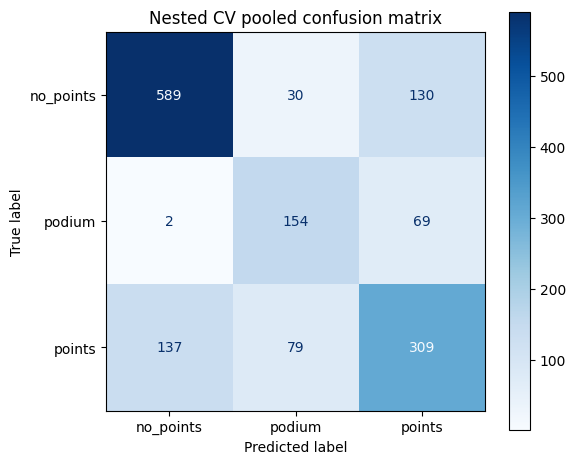

In [117]:
fold_metrics_df = pd.DataFrame({
    "fold": range(1, outer_n_splits + 1),
    "macro_f1": outer_scores_f1,
    "balanced_accuracy": outer_scores_bal_acc,
})
display(fold_metrics_df)

all_y_true = np.concatenate([pair[0] for pair in outer_predictions])
all_y_pred = np.concatenate([pair[1] for pair in outer_predictions])
print(classification_report(all_y_true, all_y_pred, target_names=le.classes_, digits=4))

cm = confusion_matrix(all_y_true, all_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Nested CV pooled confusion matrix")
plt.tight_layout()
plt.show()


# 9. Train Final Model and Evaluate Holdout

In [118]:
final_search = RandomizedSearchCV(
    estimator=estimator,
    param_distributions=param_dist,
    n_iter=search_cfg["n_iter"],
    scoring=search_cfg["scoring"],
    cv=list(make_race_time_series_splits(df_train_dev, inner_n_splits)),
    random_state=search_cfg["random_state"],
    n_jobs=config["model"].get("n_jobs", -1),
    refit=True,
)
final_search.fit(X_train_dev_arr, y_train_dev)
final_model = final_search.best_estimator_
transformed_feature_names = final_model.named_steps["sentinel"].get_feature_names_out().tolist()
final_params = final_search.best_params_
final_params_json_safe = make_json_safe_params(final_params)
holdout_pred = final_model.predict(X_holdout_arr)

label_order_names = ["podium", "points", "no_points"]
label_order_names = [name for name in label_order_names if name in le.classes_]
label_order = le.transform(label_order_names)

holdout_metrics = {
    "accuracy": accuracy_score(y_holdout, holdout_pred),
    "balanced_accuracy": balanced_accuracy_score(y_holdout, holdout_pred),
    "macro_precision": precision_score(y_holdout, holdout_pred, average="macro"),
    "macro_recall": recall_score(y_holdout, holdout_pred, average="macro"),
    "macro_f1": f1_score(y_holdout, holdout_pred, average="macro"),
    "weighted_precision": precision_score(y_holdout, holdout_pred, average="weighted"),
    "weighted_recall": recall_score(y_holdout, holdout_pred, average="weighted"),
    "weighted_f1": f1_score(y_holdout, holdout_pred, average="weighted"),
    "matthews_corrcoef": matthews_corrcoef(y_holdout, holdout_pred),
    "cohen_kappa": cohen_kappa_score(y_holdout, holdout_pred),
}

overall_metrics_df = pd.DataFrame([(name, value) for name, value in holdout_metrics.items()], columns=["metric", "value"])
overall_metrics_df["value"] = overall_metrics_df["value"].round(4)

holdout_report = classification_report(
    y_holdout,
    holdout_pred,
    labels=label_order,
    target_names=label_order_names,
    digits=4,
    output_dict=True,
)
per_label_metrics_df = (
    pd.DataFrame(holdout_report)
    .T
    .loc[label_order_names, ["precision", "recall", "f1-score", "support"]]
    .rename(columns={"f1-score": "f1_score"})
)
per_label_metrics_df[["precision", "recall", "f1_score"]] = per_label_metrics_df[["precision", "recall", "f1_score"]].round(4)
per_label_metrics_df["support"] = per_label_metrics_df["support"].astype(int)

holdout_cm = confusion_matrix(y_holdout, holdout_pred, labels=label_order)
holdout_cm_df = pd.DataFrame(
    holdout_cm,
    index=[f"true_{name}" for name in label_order_names],
    columns=[f"pred_{name}" for name in label_order_names],
)

print("Best train/development search params:")
print(json.dumps(final_params_json_safe, indent=2))
print(f"Best train/development CV score: {final_search.best_score_:.4f}")
print("\nOverall holdout metrics:")
display(overall_metrics_df)
print("\nPer-label holdout metrics:")
display(per_label_metrics_df)
print("\nHoldout confusion matrix table:")
display(holdout_cm_df)


Best train/development search params:
{
  "svc__kernel": "rbf",
  "svc__gamma": 0.003,
  "svc__class_weight": {
    "no_points": 1.0,
    "podium": 1.0,
    "points": 1.1
  },
  "svc__C": 100.0,
  "scaler": "RobustScaler"
}
Best train/development CV score: 0.6983

Overall holdout metrics:


,metric,value
0,accuracy,0.6806
1,balanced_accuracy,0.6974
2,macro_precision,0.6703
3,macro_recall,0.6974
4,macro_f1,0.6818
5,weighted_precision,0.6772
6,weighted_recall,0.6806
7,weighted_f1,0.6778
8,matthews_corrcoef,0.4777
9,cohen_kappa,0.4771



Per-label holdout metrics:


,precision,recall,f1_score,support
podium,0.6941,0.8194,0.7516,72
points,0.5677,0.5238,0.5449,168
no_points,0.7490,0.7490,0.7490,239



Holdout confusion matrix table:


,pred_podium,pred_points,pred_no_points
true_podium,59,12,1
true_points,21,88,59
true_no_points,5,55,179


# 10. Save Model and Results

In [119]:
MODEL_DIR = REPO_ROOT / "models_training" / "svm"
MODEL_PATH = MODEL_DIR / "svm_final_model.joblib"

model_artifact = {
    "model": final_model,
    "onehot_encoder": onehot_encoder,
    "raw_feature_names": raw_feature_names,
    "numeric_feature_names": numeric_cols,
    "categorical_feature_names": categorical_cols,
    "encoded_feature_names": transformed_feature_names,
    "sentinel_impute_columns": sentinel_impute_cols,
    "label_encoder": le,
}
joblib.dump(model_artifact, MODEL_PATH)
print(f"Model artifact saved to: {MODEL_PATH}")

BEST_PARAMS_PATH = REPO_ROOT / "json-parameters" / "svm" / "svm_best_optimization_params.json"
output_record = {
    "features_used": transformed_feature_names,
    "raw_features_used": raw_feature_names,
    "categorical_features_encoded": categorical_cols,
    "sentinel_impute_columns": sentinel_impute_cols,
    "features_excluded": excluded_cols,
    "holdout_split": {
        "train_development_years": sorted(int(year) for year in df_train_dev["year"].unique()),
        "holdout_test_years": test_years,
        "excluded_years": exclude_years,
        "train_development_rows": int(len(df_train_dev)),
        "holdout_test_rows": int(len(df_holdout)),
        "train_development_races": int(df_train_dev["raceId"].nunique()),
        "holdout_test_races": int(df_holdout["raceId"].nunique()),
    },
    "nested_cv_summary": {
        "outer_folds": outer_n_splits,
        "inner_folds": inner_n_splits,
        "mean_macro_f1": round(float(np.mean(outer_scores_f1)), 4),
        "std_macro_f1": round(float(np.std(outer_scores_f1)), 4),
        "mean_balanced_acc": round(float(np.mean(outer_scores_bal_acc)), 4),
        "std_balanced_acc": round(float(np.std(outer_scores_bal_acc)), 4),
    },
    "final_search_summary": {
        "search_method": "RandomizedSearchCV",
        "n_iter": search_cfg["n_iter"],
        "scoring": search_cfg["scoring"],
        "cv_folds": inner_n_splits,
        "best_cv_score": round(float(final_search.best_score_), 4),
    },
    "final_holdout_metrics": {name: round(float(value), 4) for name, value in holdout_metrics.items()},
    "final_holdout_per_label_metrics": per_label_metrics_df.to_dict(orient="index"),
    "final_holdout_classification_report": holdout_report,
    "final_holdout_confusion_matrix": {
        "labels": label_order_names,
        "matrix": holdout_cm.tolist(),
    },
    "final_hyperparameters": final_params_json_safe,
    "model_path": str(MODEL_PATH),
}

with open(BEST_PARAMS_PATH, "w") as f:
    json.dump(output_record, f, indent=2, default=str)

print(f"Best params and metrics saved to: {BEST_PARAMS_PATH}")
print(json.dumps(output_record, indent=2, default=str))


Model artifact saved to: /Users/khaido/Pisa/Data Mining/project/formula1_data_mining_project/models_training/svm/svm_final_model.joblib
Best params and metrics saved to: /Users/khaido/Pisa/Data Mining/project/formula1_data_mining_project/json-parameters/svm/svm_best_optimization_params.json
{
  "features_used": [
    "grid",
    "qualifying_position",
    "driver_std_position_prev",
    "constructor_std_position_prev",
    "driver_avg_position_last3",
    "driver_podium_rate_last10",
    "driver_points_avg_last3",
    "constructor_avg_position_last3",
    "driver_avg_position_at_circuit",
    "teammate_h2h_avg_position_delta",
    "driver_dnf_rate_historical",
    "points_gap_to_leader",
    "grid_missing",
    "qualifying_position_missing",
    "driver_std_position_prev_missing",
    "constructor_std_position_prev_missing",
    "driver_avg_position_last3_missing",
    "driver_podium_rate_last10_missing",
    "driver_points_avg_last3_missing",
    "constructor_avg_position_last3_missin